In [1]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.set_default()

Importing Library
done


In [2]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [3]:
# Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                        7, 8, 9, 10, 11,
                        12, 13, 14, 15, 16,
                        17, 18, 19, 20, 21,
                        22, 23, 24], dtype=int)

# Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])

# Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [4]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

In [5]:
PJ_list = [1, 3, 4, 5,
           6, 7, 8, 9, 10,
           11, 12, 13, 14, 15,
           16, 17, 18, 19, 20,
           21, 22, 23, 24, 25,
           26, 27, 28, 29, 30,
           32, 33, 34, 35,
           36, 37, 38, 39, 40,
           41, 42, 43, 44, 45,
           46, 48, 49, 50]
f0 = np.loadtxt('results/insitu_fit/result_PJ' +
                str(PJ_list[0]).zfill(2)+'_PJ'+str(PJ_list[-1]).zfill(2)+'.txt')

[]

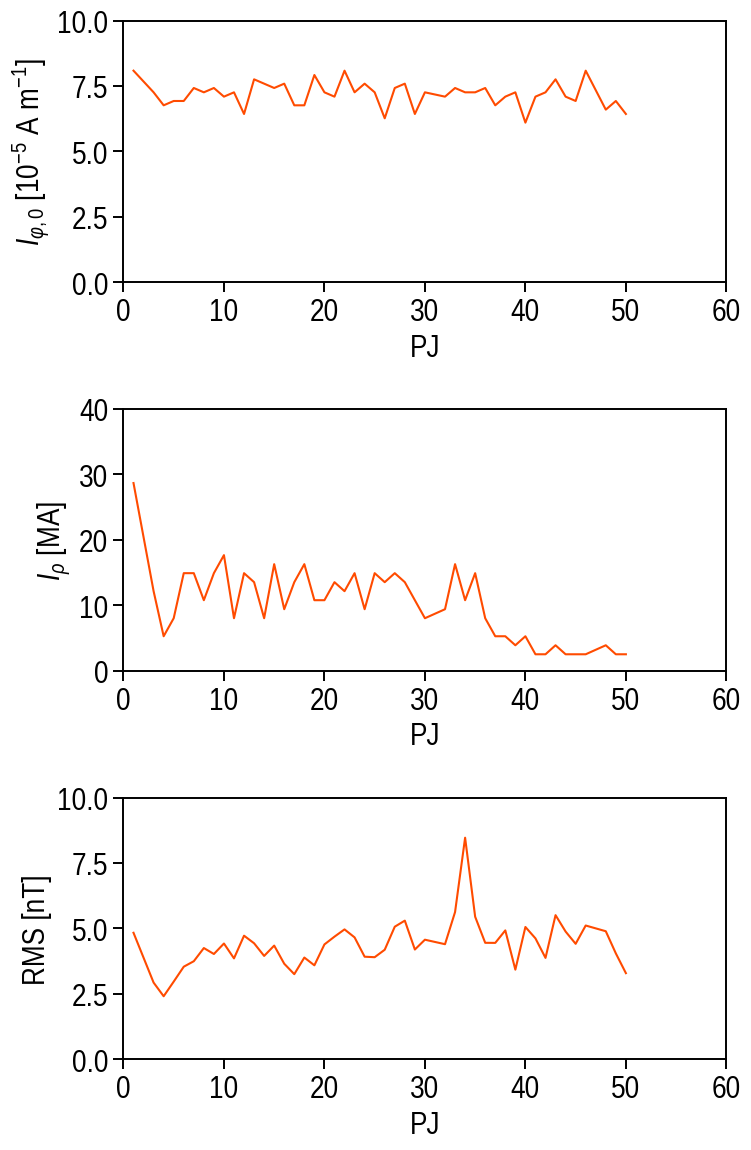

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
for i in range(3):
    ax[i].set_xlabel('PJ')
    ax[i].set_xlim(0, 60)
ax[0].set_ylabel(r'$I_{\varphi,0}$ [$10^{-5}$ A m$^{-1}$]')
ax[0].set_ylim(0, 10)
ax[1].set_ylabel(r'$I_{\rho}$ [MA]')
ax[1].set_ylim(0, 40)
ax[2].set_ylabel(r'RMS [nT]')
ax[2].set_ylim(0, 10)

ax[0].plot(f0[:, 0], f0[:, 1]*1E+5)
ax[1].plot(f0[:, 0], f0[:, 2])
ax[2].plot(f0[:, 0], f0[:, 3])

fig.tight_layout()
plt.plot()